# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


This Zillow dataset contains information about housing data for real estate property. Many of the features that are included is logistical information about the property such as square footage, number of bed and bathrooms, location of the property, year the property was built, and etc. With this information, the objective of this dataset is to be able to see with unsupervised learning to predict based on the features of the property it's market value to help make better predictions on the actual value and worth investment of the real estate. 

**1.2:**  How will your solution be used?


Understanding the value of real estate property can be highly beneficial for many people. For home buyers, buying the most affordable home for the conditions that they want. Even finding the right approach of what they can afford according to the laws and regulations of the state or locally. For government, they can understand what are the best practices in implementing laws and regulations to help people in need. Ultimately, analysis and finding solutions using this dataset is important in helping many people in different stages to benefit themselves and others. 

**1.3:**  How should success (or failure) be measured?


Success or failure should be measured with Mean Absolute Error or Root Mean Squared Error. Finding a lower MAE or RMSE shows a success. Another way to find success if measuring the correlation. Having a higher R squared means a success as well. From a business perspective, success should be defined by accurate pricing that supports better decision making for buyers and seller. Failure occurs when prediction errors are higher and lead to poor decision making. 

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
df.columns

Index(['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid',
       'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingclasstypeid',
       'buildingqualitytypeid', 'calculatedbathnbr', 'decktypeid',
       'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet',
       'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15',
       'finishedsquarefeet50', 'finishedsquarefeet6', 'fips', 'fireplacecnt',
       'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
       'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'rawcensustractandblock', 'regionidcity',
       'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt',
       'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid',
       'unitcnt', 'yardbuildingsqft17', 'yardbuildin

In [3]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [5]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [6]:
df.isnull().mean() * 100

parcelid                         0.000000
airconditioningtypeid           67.779882
architecturalstyletypeid        99.733292
basementsqft                    99.935578
bathroomcnt                      0.043807
bedroomcnt                       0.043807
buildingclasstypeid             99.980673
buildingqualitytypeid           35.823895
calculatedbathnbr                0.837489
decktypeid                      99.208895
finishedfloor1squarefeet        92.221664
calculatedfinishedsquarefeet     0.302784
finishedsquarefeet12             4.754358
finishedsquarefeet13            99.945885
finishedsquarefeet15            96.099880
finishedsquarefeet50            92.221664
finishedsquarefeet6             99.502661
fips                             0.043807
fireplacecnt                    89.320088
fullbathcnt                      0.837489
garagecarcnt                    67.118910
garagetotalsqft                 67.118910
hashottuborspa                  98.017085
heatingorsystemtypeid           36

The dataset contains a mixture of numerical and categorical features. Numerical columns include variables such as property size, number of rooms, and other quantitative attributes, while categorical columns represent location or descriptive information.

Initial inspection shows that several columns contain missing values, with some features having a significant proportion of missing data. These will need to be addressed during preprocessing.

The number of unique values varies across features. Some categorical variables have high cardinality, which may impact how they are encoded or whether they are retained in the model.

Many of the features appear relevant for predicting property value, particularly those related to size, structure, and location. However, columns with excessive missing values or limited predictive value may need to be removed.

The target variable for this analysis is taxvaluedollarcnt, which represents the assessed property value.

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Categorical features in the dataset include variables that represent labels or groupings rather than continuous numerical values. These include columns such as propertyzoningdesc and propertycountylandusecode, which describe zoning and land use classifications.

Additionally, features like regionidcity, regionidcounty, and regionidzip are also treated as categorical, even though they are stored as numerical values, because they represent geographic categories rather than meaningful numeric quantities.

These features will require encoding (e.g., one-hot encoding) before being used in machine learning models.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

At first glance, some features appear to have limited usefulness for predicting property value. Columns that serve as identifiers, such as parcel or property IDs, are likely not useful since they uniquely identify each observation but do not provide predictive information.

Additionally, features with a very high percentage of missing values may not be useful without significant preprocessing, as they provide little reliable information in their current form.

Some categorical features may also have extremely high cardinality (a large number of unique values), which can make them difficult to encode effectively and may not contribute meaningfully to prediction without further feature engineering.

These features may be considered for removal or transformation during later stages of the analysis. For example, the parcelid column appears to be an identifier and is unlikely to contribute to prediction.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Yes, several features appear to be largely unusable due to a high percentage of missing values. For example, the column basementsqft has over 99% missing data.

With such a high proportion of missing values, this feature provides very little usable information and would require extensive imputation to be meaningful. As a result, it is likely more practical to remove this feature from the dataset rather than attempt to fill in the missing values.

Other columns such as architecturalstyletypeid and buildingclasstypeid also have similarly high levels of missing data and may be considered for removal.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Yes, some features appear to be less useful due to having a very large number of unique values. For example, the column parcelid contains a unique value for nearly every observation.

Because this feature acts as an identifier rather than providing meaningful information about the property, it is unlikely to be useful for predicting the target variable. As a result, it may be removed from the dataset.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

**Histograms - All Features**

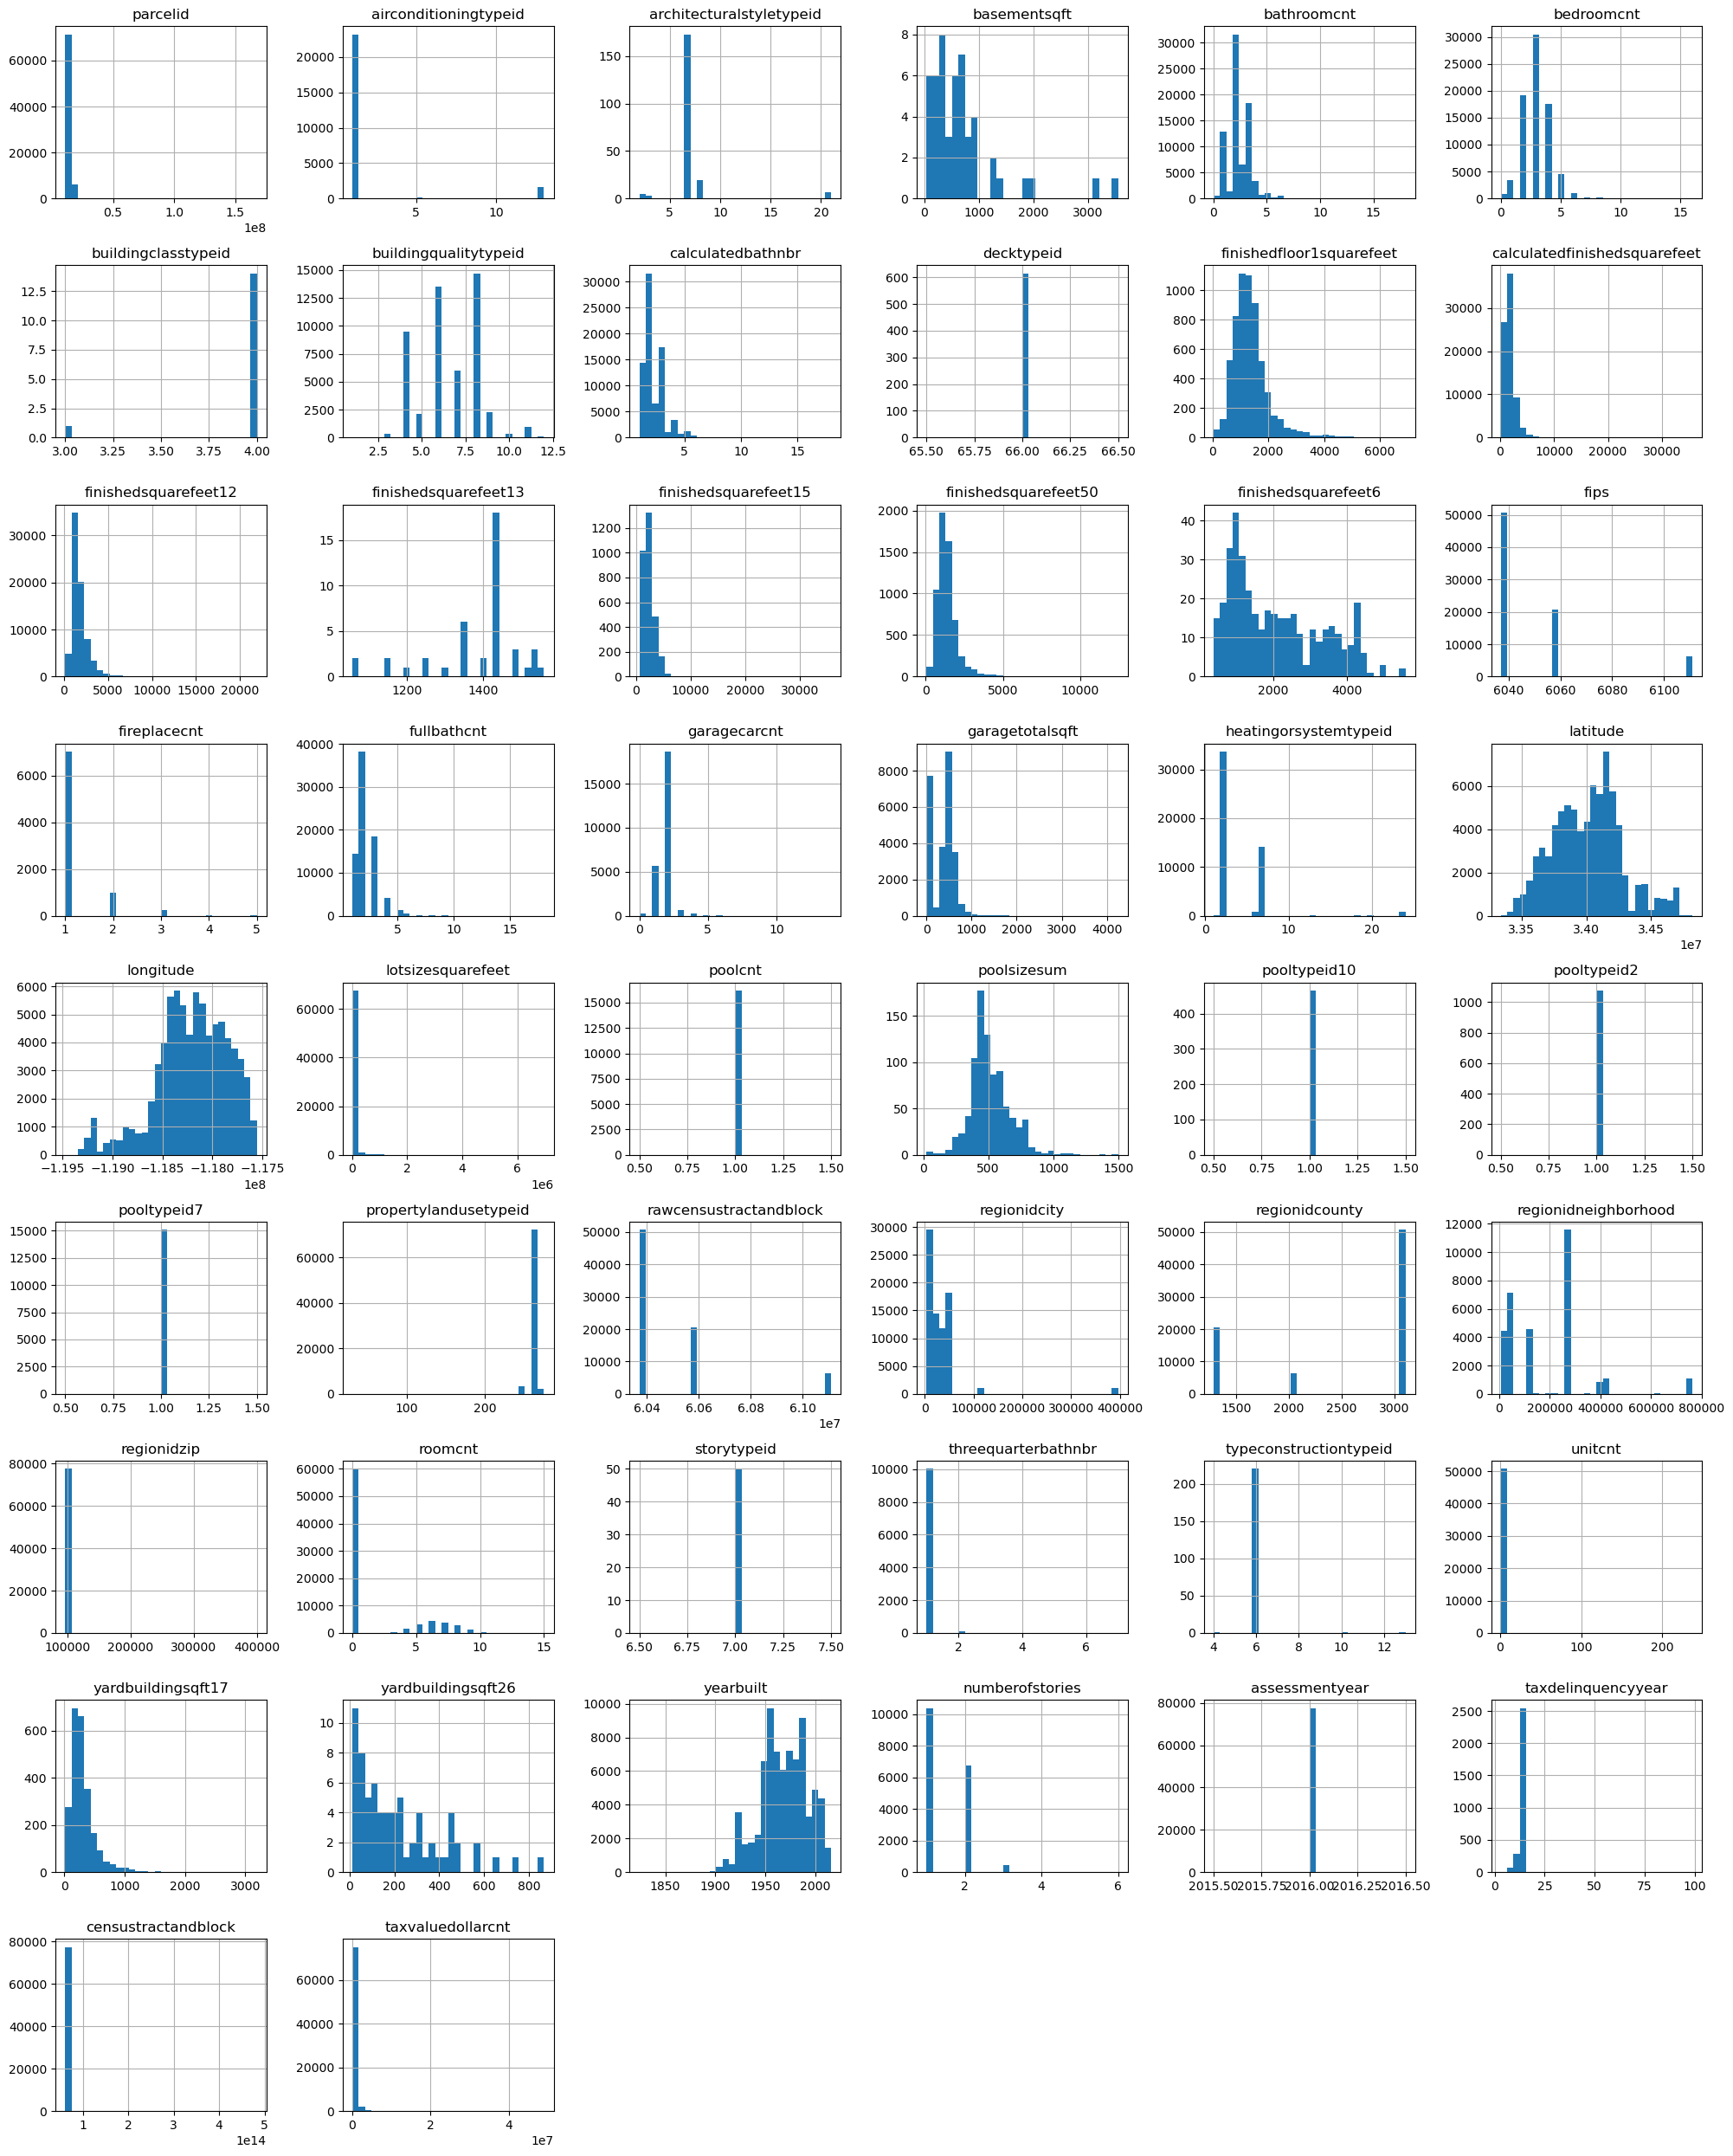

In [15]:
import matplotlib.pyplot as plt

# Plot histograms for all features
df.hist(figsize=(20, 25), layout=(-1, 6), bins=30)

plt.tight_layout()
plt.show()

Histograms were generated for all features to provide an overview of their distributions. Many numerical features appear to be skewed, and several contain extreme values or outliers. Some features also show a high concentration of zeros, which may indicate missing or sparse data.

**Target Variable: taxvaluedollarcnt**

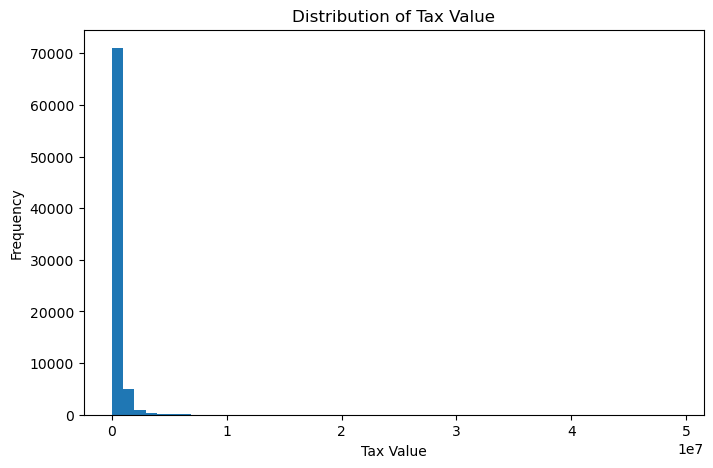

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['taxvaluedollarcnt'], bins=50)
plt.title("Distribution of Tax Value")
plt.xlabel("Tax Value")
plt.ylabel("Frequency")
plt.show()

The target variable taxvaluedollarcnt is highly right-skewed, with most properties clustered at lower values and a small number of extremely high-value properties. This indicates the presence of significant outliers, which may impact model performance.

**Target Variable: lotsizesquarefeet**

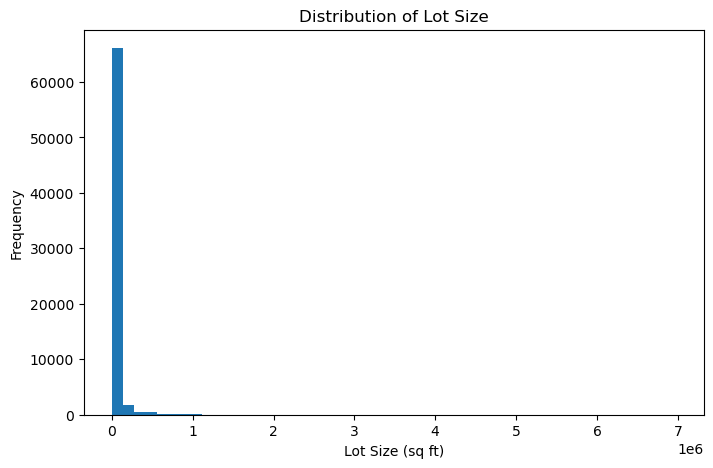

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['lotsizesquarefeet'].dropna(), bins=50)
plt.title("Distribution of Lot Size")
plt.xlabel("Lot Size (sq ft)")
plt.ylabel("Frequency")
plt.show()

The lotsizesquarefeet feature is also right-skewed, with most properties having relatively small lot sizes and a few extremely large values. This suggests the presence of outliers and potential scaling issues.

**Target Variable: yearbuilt**

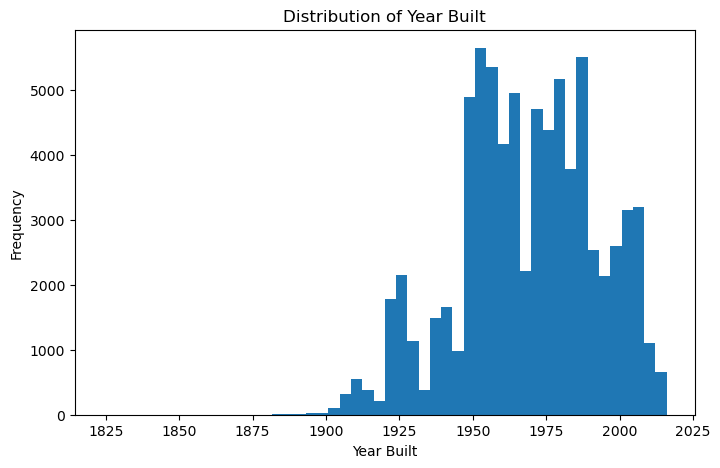

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df['yearbuilt'].dropna(), bins=50)
plt.title("Distribution of Year Built")
plt.xlabel("Year Built")
plt.ylabel("Frequency")
plt.show()

The yearbuilt feature shows a concentration of properties built in more recent decades, with fewer older homes. This feature appears more normally distributed compared to others and may provide useful predictive information.

**Target Variable: garagecarcnt**

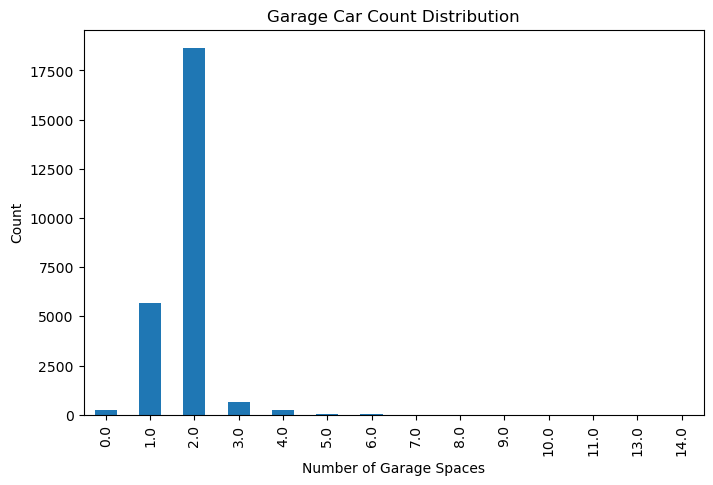

In [11]:
plt.figure(figsize=(8,5))
df['garagecarcnt'].value_counts().sort_index().plot(kind='bar')
plt.title("Garage Car Count Distribution")
plt.xlabel("Number of Garage Spaces")
plt.ylabel("Count")
plt.show()

The garagecarcnt feature is discrete, with most properties having 1–2 garage spaces and fewer properties having larger capacities. This feature has a clear distribution and may be useful in predicting property value.

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


The target variable taxvaluedollarcnt exhibits a strongly right-skewed distribution, with most properties concentrated at lower values and a small number of very high-value outliers. This suggests the presence of extreme values that could impact model performance. The feature lotsizesquarefeet shows a similar right-skewed pattern, indicating that while most properties have relatively small lot sizes, a few have exceptionally large lots, which may require transformation or scaling. In contrast, yearbuilt appears more evenly distributed, with a concentration of homes built in recent decades, making it a potentially useful predictor of property value. The feature garagecarcnt is discrete and shows that most properties have one or two garage spaces, with fewer properties having larger capacities. These features were chosen because they exhibit different types of distributions and characteristics, allowing for a more comprehensive understanding of the dataset’s structure and potential modeling challenges.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [16]:
def drop_unnecessary_features(df):
    df_clean = df.copy()
    
    cols_to_drop = [
        'parcelid',
        'regionidzip',
        'regionidcity',
        'regionidcounty',
        'rawcensustractandblock',
        'censustractandblock',
        'propertycountylandusecode',
        'propertyzoningdesc'
    ]
    
    df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')
    
    return df_clean


df_dropped = drop_unnecessary_features(df)
df_dropped.head()

,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,...,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,taxvaluedollarcnt
0,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,...,NaN,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,1023282.0
1,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,...,NaN,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,464000.0
2,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,564778.0
3,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,...,1.0,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,145143.0
4,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,...,1.0,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,119407.0


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


Several features were removed because they are not suitable for the regression task. The parcelid column was dropped because it is a unique identifier and does not provide predictive information.

Geographic identifier features such as regionidzip, regionidcity, and regionidcounty were also removed because they represent categorical labels with high cardinality, making them difficult to encode effectively.

Additionally, features like rawcensustractandblock and censustractandblock were dropped because they contain highly specific location information that is unlikely to generalize well without advanced feature engineering.

Finally, columns such as propertycountylandusecode and propertyzoningdesc were removed due to their complexity and high number of unique values, which may not provide meaningful predictive value in this context.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [17]:
# Check percent missing after Part 3.A
missing_percent = df_dropped.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

buildingclasstypeid             99.980673
finishedsquarefeet13            99.945885
basementsqft                    99.935578
storytypeid                     99.935578
yardbuildingsqft26              99.909809
fireplaceflag                   99.778388
architecturalstyletypeid        99.733292
typeconstructiontypeid          99.712677
finishedsquarefeet6             99.502661
pooltypeid10                    99.400874
decktypeid                      99.208895
poolsizesum                     98.880342
pooltypeid2                     98.616211
hashottuborspa                  98.017085
yardbuildingsqft17              96.916754
taxdelinquencyyear              96.263513
taxdelinquencyflag              96.263513
finishedsquarefeet15            96.099880
finishedfloor1squarefeet        92.221664
finishedsquarefeet50            92.221664
fireplacecnt                    89.320088
threequarterbathnbr             86.978985
pooltypeid7                     80.571554
poolcnt                         79

In [18]:
def drop_high_null_features(df, threshold=90):
    df_clean = df.copy()
    
    missing_percent = df_clean.isnull().mean() * 100
    cols_to_drop = missing_percent[missing_percent >= threshold].index.tolist()
    
    df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')
    
    return df_clean, cols_to_drop, missing_percent


df_null_dropped, dropped_null_cols, missing_percent_after_drop = drop_high_null_features(df_dropped, threshold=90)

print("Dropped columns with >= 90% missing values:")
print(dropped_null_cols)

Dropped columns with >= 90% missing values:
['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'hashottuborspa', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'storytypeid', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'fireplaceflag', 'taxdelinquencyflag', 'taxdelinquencyyear']


In [19]:
# Show the missing percentages for the columns that were removed
missing_percent_after_drop.loc[dropped_null_cols].sort_values(ascending=False)

buildingclasstypeid         99.980673
finishedsquarefeet13        99.945885
storytypeid                 99.935578
basementsqft                99.935578
yardbuildingsqft26          99.909809
fireplaceflag               99.778388
architecturalstyletypeid    99.733292
typeconstructiontypeid      99.712677
finishedsquarefeet6         99.502661
pooltypeid10                99.400874
decktypeid                  99.208895
poolsizesum                 98.880342
pooltypeid2                 98.616211
hashottuborspa              98.017085
yardbuildingsqft17          96.916754
taxdelinquencyflag          96.263513
taxdelinquencyyear          96.263513
finishedsquarefeet15        96.099880
finishedfloor1squarefeet    92.221664
finishedsquarefeet50        92.221664
dtype: float64

In [21]:
# Cleaned dataframe
df_null_dropped.head()

,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fireplacecnt,fullbathcnt,...,pooltypeid7,propertylandusetypeid,regionidneighborhood,roomcnt,threequarterbathnbr,unitcnt,yearbuilt,numberofstories,assessmentyear,taxvaluedollarcnt
0,NaN,3.5,4.0,NaN,3.5,3100.0,3100.0,6059.0,NaN,3.0,...,NaN,261.0,NaN,0.0,1.0,NaN,1998.0,NaN,2016.0,1023282.0
1,NaN,1.0,2.0,NaN,1.0,1465.0,1465.0,6111.0,1.0,1.0,...,NaN,261.0,NaN,5.0,NaN,NaN,1967.0,1.0,2016.0,464000.0
2,NaN,2.0,3.0,NaN,2.0,1243.0,1243.0,6059.0,NaN,2.0,...,1.0,261.0,NaN,6.0,NaN,NaN,1962.0,1.0,2016.0,564778.0
3,NaN,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,NaN,3.0,...,1.0,261.0,NaN,0.0,NaN,1.0,1970.0,NaN,2016.0,145143.0
4,1.0,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,NaN,3.0,...,1.0,266.0,268548.0,0.0,NaN,1.0,1964.0,NaN,2016.0,119407.0


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



We defined “too many” missing values as 90% or more null values. This threshold was chosen because features with that much missing data contain very little usable information and would require heavy imputation, which could introduce noise and reduce model reliability. In this dataset, several columns met that criterion, such as basementsqft, architecturalstyletypeid, buildingclasstypeid, finishedsquarefeet13, storytypeid, and fireplaceflag. These features have so few observed values that they are unlikely to contribute meaningful predictive power. We chose to remove them rather than impute them, since the remaining non-null values are too sparse to reliably represent the overall population. We used a conservative threshold of 90% so that features with substantial but still potentially useful information were retained for later imputation.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [22]:
# Check how many target values are missing
df_null_dropped['taxvaluedollarcnt'].isnull().sum()

np.int64(35)

In [23]:
def drop_problematic_samples(df, target_col='taxvaluedollarcnt', row_null_threshold=0.5):
    df_clean = df.copy()
    
    original_rows = df_clean.shape[0]
    
    # 1. Drop rows with missing target
    df_clean = df_clean.dropna(subset=[target_col])
    after_target_drop = df_clean.shape[0]
    
    # 2. Drop rows with too many missing values
    row_missing_fraction = df_clean.isnull().mean(axis=1)
    df_clean = df_clean[row_missing_fraction <= row_null_threshold]
    after_null_row_drop = df_clean.shape[0]
    
    # 3. Drop extreme outliers in the target using IQR
    Q1 = df_clean[target_col].quantile(0.25)
    Q3 = df_clean[target_col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_clean = df_clean[
        (df_clean[target_col] >= lower_bound) &
        (df_clean[target_col] <= upper_bound)
    ]
    after_outlier_drop = df_clean.shape[0]
    
    print(f"Original number of rows: {original_rows}")
    print(f"After dropping null targets: {after_target_drop}")
    print(f"After dropping rows with > {row_null_threshold*100:.0f}% missing values: {after_null_row_drop}")
    print(f"After dropping target outliers: {after_outlier_drop}")
    
    return df_clean


df_sample_cleaned = drop_problematic_samples(
    df_null_dropped,
    target_col='taxvaluedollarcnt',
    row_null_threshold=0.5
)

df_sample_cleaned.head()

Original number of rows: 77613
After dropping null targets: 77578
After dropping rows with > 50% missing values: 77325
After dropping target outliers: 72193


,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fireplacecnt,fullbathcnt,...,pooltypeid7,propertylandusetypeid,regionidneighborhood,roomcnt,threequarterbathnbr,unitcnt,yearbuilt,numberofstories,assessmentyear,taxvaluedollarcnt
0,NaN,3.5,4.0,NaN,3.5,3100.0,3100.0,6059.0,NaN,3.0,...,NaN,261.0,NaN,0.0,1.0,NaN,1998.0,NaN,2016.0,1023282.0
1,NaN,1.0,2.0,NaN,1.0,1465.0,1465.0,6111.0,1.0,1.0,...,NaN,261.0,NaN,5.0,NaN,NaN,1967.0,1.0,2016.0,464000.0
2,NaN,2.0,3.0,NaN,2.0,1243.0,1243.0,6059.0,NaN,2.0,...,1.0,261.0,NaN,6.0,NaN,NaN,1962.0,1.0,2016.0,564778.0
3,NaN,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,NaN,3.0,...,1.0,261.0,NaN,0.0,NaN,1.0,1970.0,NaN,2016.0,145143.0
4,1.0,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,NaN,3.0,...,1.0,266.0,268548.0,0.0,NaN,1.0,1964.0,NaN,2016.0,119407.0


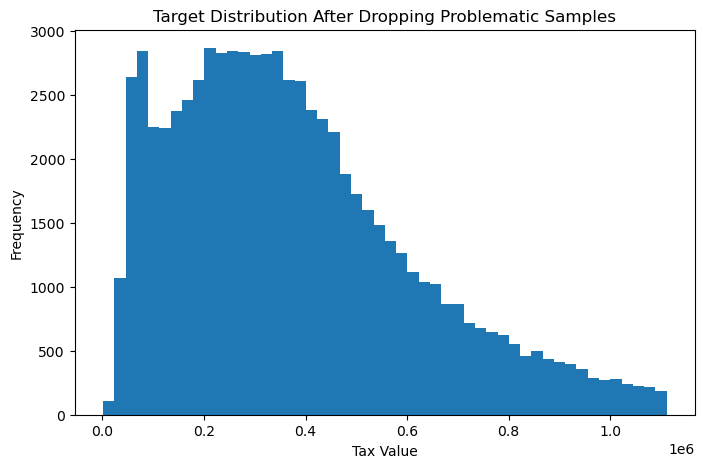

In [24]:
plt.figure(figsize=(8,5))
plt.hist(df_sample_cleaned['taxvaluedollarcnt'], bins=50)
plt.title("Target Distribution After Dropping Problematic Samples")
plt.xlabel("Tax Value")
plt.ylabel("Frequency")
plt.show()

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


We removed problematic samples based on three criteria. First, we dropped rows with missing values in the target variable taxvaluedollarcnt, since these cannot be used for supervised learning. Second, we removed rows with more than 50% missing values, as they contain insufficient information for reliable imputation. Finally, we removed extreme outliers in the target variable using the IQR rule. This was necessary because the target distribution was highly right-skewed, with a small number of very large values. After cleaning, the distribution of the target variable became more consistent while still retaining its natural skew. Overall, this process reduced noise in the dataset while preserving the majority of observations for modeling.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [25]:
def impute_missing_values(df):
    df_clean = df.copy()
    
    # Separate numerical and categorical columns
    num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    
    # Numerical → median
    for col in num_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    # Categorical → mode
    for col in cat_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    
    return df_clean


df_imputed = impute_missing_values(df_sample_cleaned)

# Check if any nulls remain
df_imputed.isnull().sum().sum()

np.int64(0)

In [26]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72193 entries, 0 to 77612
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   airconditioningtypeid         72193 non-null  float64
 1   bathroomcnt                   72193 non-null  float64
 2   bedroomcnt                    72193 non-null  float64
 3   buildingqualitytypeid         72193 non-null  float64
 4   calculatedbathnbr             72193 non-null  float64
 5   calculatedfinishedsquarefeet  72193 non-null  float64
 6   finishedsquarefeet12          72193 non-null  float64
 7   fips                          72193 non-null  float64
 8   fireplacecnt                  72193 non-null  float64
 9   fullbathcnt                   72193 non-null  float64
 10  garagecarcnt                  72193 non-null  float64
 11  garagetotalsqft               72193 non-null  float64
 12  heatingorsystemtypeid         72193 non-null  float64
 13  latitu

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


To handle the remaining missing values, we applied different imputation methods based on feature type. For numerical features, we used median imputation because many of the variables in the dataset are skewed and contain outliers. The median is more robust than the mean in these cases and provides a more reliable estimate of central tendency.

For categorical features, we used mode imputation, replacing missing values with the most frequent category. This approach preserves the most common class and is appropriate for categorical data.

This combination of median and mode imputation ensures that all missing values are addressed while minimizing distortion of the original data distribution.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [27]:
df_imputed.select_dtypes(include=['object']).columns

Index([], dtype='object')

## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

**Correlation Matrix**

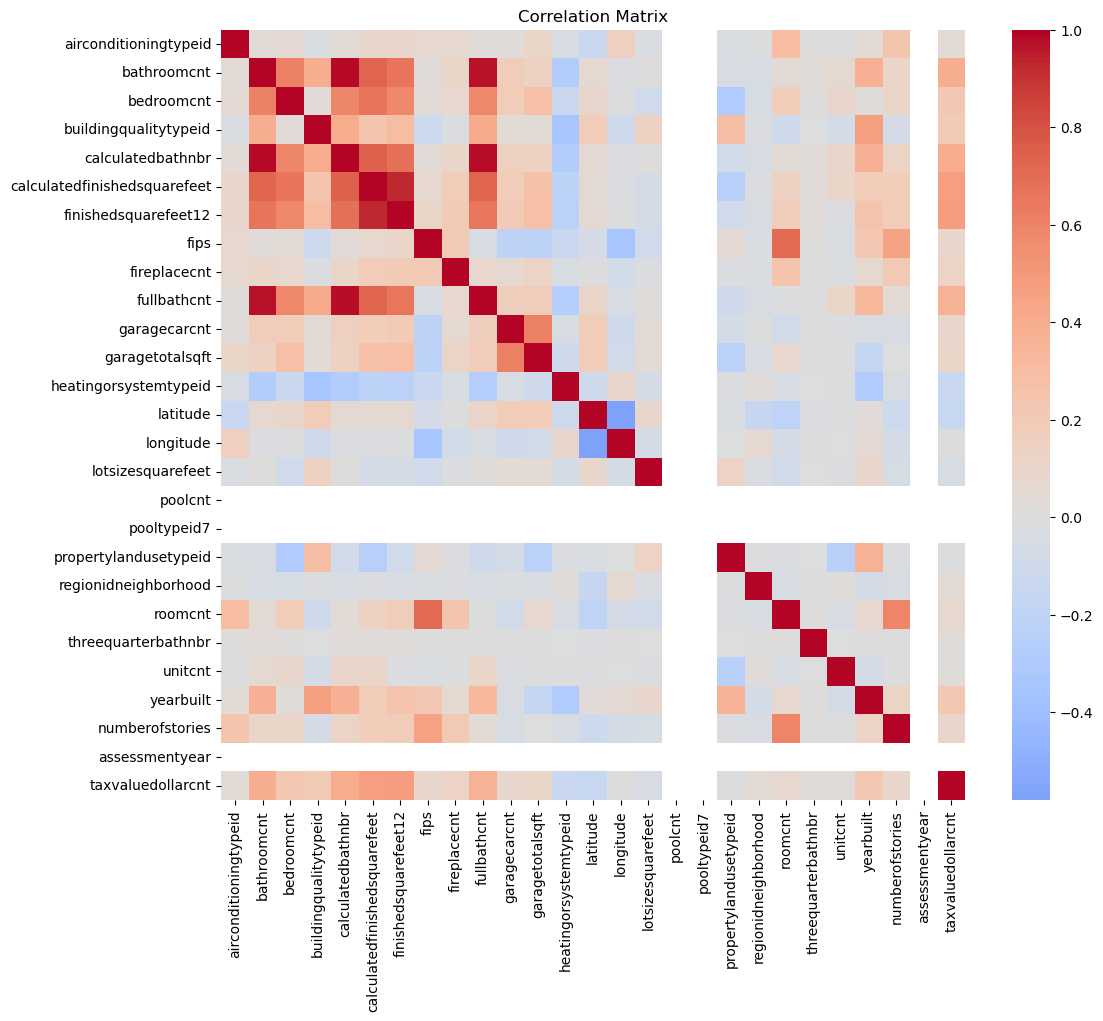

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute pairwise correlations between all numerical features
corr_matrix = df_imputed.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

# Visualize correlations using a heatmap to identify relationships

In [ ]:
# Extract correlation values specifically with the target variable
target_corr = corr_matrix['taxvaluedollarcnt'].sort_values(ascending=False)

target_corr.head(10)

taxvaluedollarcnt               1.000000
finishedsquarefeet12            0.480140
calculatedfinishedsquarefeet    0.474307
calculatedbathnbr               0.403380
bathroomcnt                     0.395146
fullbathcnt                     0.375483
bedroomcnt                      0.228156
yearbuilt                       0.221200
buildingqualitytypeid           0.202420
fireplacecnt                    0.127435
Name: taxvaluedollarcnt, dtype: float64

In [30]:
target_corr.tail(10)

threequarterbathnbr      0.021071
unitcnt                  0.020646
longitude                0.000770
propertylandusetypeid   -0.006541
lotsizesquarefeet       -0.043703
heatingorsystemtypeid   -0.145577
latitude                -0.153251
poolcnt                       NaN
pooltypeid7                   NaN
assessmentyear                NaN
Name: taxvaluedollarcnt, dtype: float64

**F-Statistic**

In [ ]:
# Compute F-statistics to measure the strength of relationship between each feature and the target

from sklearn.feature_selection import f_regression
import numpy as np

X = df_imputed.drop('taxvaluedollarcnt', axis=1)
y = df_imputed['taxvaluedollarcnt']

f_values, p_values = f_regression(X, y)

f_df = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': f_values,
    'p-value': p_values
}).sort_values(by='F-Score', ascending=False)

f_df.head(10)

,Feature,F-Score,p-value
6,finishedsquarefeet12,21628.678699,0.0
5,calculatedfinishedsquarefeet,20954.733192,0.0
4,calculatedbathnbr,14029.368192,0.0
1,bathroomcnt,13357.550023,0.0
9,fullbathcnt,11848.509698,0.0
2,bedroomcnt,3964.277094,0.0
23,yearbuilt,3713.994757,0.0
3,buildingqualitytypeid,3084.315680,0.0
13,latitude,1736.242751,0.0
12,heatingorsystemtypeid,1563.046419,0.0


**Bar Plot**

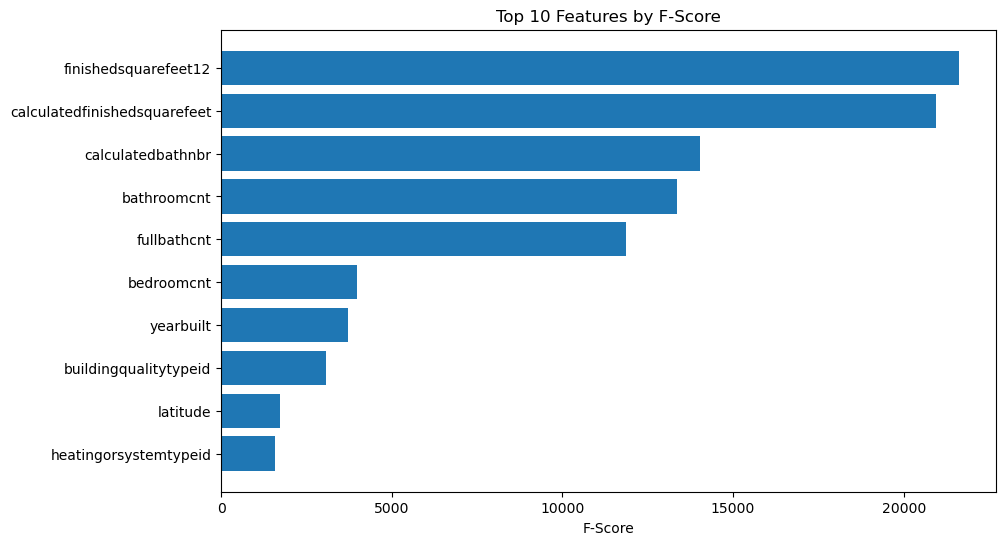

In [ ]:
# Plot the top features based on F-score for easier comparison

plt.figure(figsize=(10,6))
plt.barh(f_df['Feature'][:10], f_df['F-Score'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Features by F-Score")
plt.xlabel("F-Score")
plt.show()

**Forward Feature Selection**

In [ ]:
# Use forward feature selection to identify important features

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

model = LinearRegression()

forward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction='forward'
)

forward_selector.fit(X, y)

forward_features = X.columns[forward_selector.get_support()]
forward_features

Index(['finishedsquarefeet12', 'latitude', 'longitude', 'roomcnt',
       'yearbuilt'],
      dtype='object')

**Backward Feature Selection**

In [ ]:
# Use backward feature selection to identify important features

backward_selector = SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction='backward'
)

backward_selector.fit(X, y)

backward_features = X.columns[backward_selector.get_support()]
backward_features

Index(['finishedsquarefeet12', 'latitude', 'longitude', 'roomcnt',
       'yearbuilt'],
      dtype='object')

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The correlation matrix shows that several features related to property size and structure, such as finishedsquarefeet12, calculatedfinishedsquarefeet, bathroomcnt, and fullbathcnt, have strong positive relationships with the target variable taxvaluedollarcnt. These features are also highly correlated with each other, indicating potential multicollinearity, as they all capture similar aspects of property size and livability. The F-statistic analysis supports these findings, ranking many of the same features as the most important predictors of the target variable. Additionally, both forward and backward feature selection methods selected an identical subset of features, including finishedsquarefeet12, latitude, longitude, roomcnt, and yearbuilt, highlighting the importance of property size, location, and age. Overall, the different methods largely agree, reinforcing the conclusion that structural and location-based features are the most influential in predicting property value.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

In [ ]:
# Reducing overplotting and makes patterns easier to see because they were not as clear
df_plot = df_imputed.sample(5000, random_state=42)

**Square Footage vs Price**

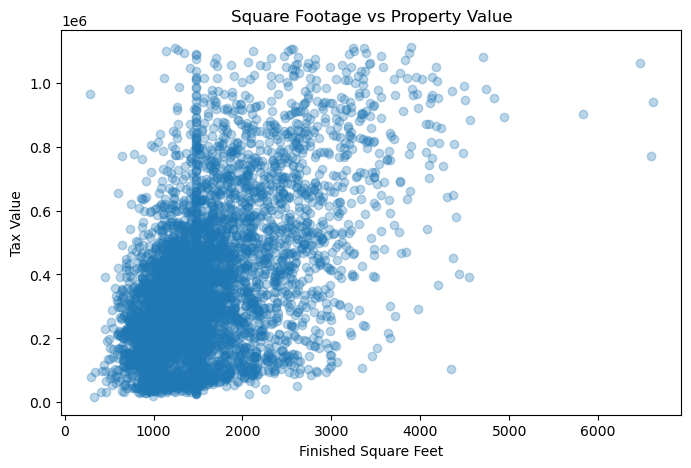

In [41]:
# Scatter plot: square footage vs target value
plt.figure(figsize=(8,5))
plt.scatter(df_plot['finishedsquarefeet12'], df_plot['taxvaluedollarcnt'], alpha=0.3)
plt.xlabel("Finished Square Feet")
plt.ylabel("Tax Value")
plt.title("Square Footage vs Property Value")
plt.show()

There is a clear positive relationship between finished square footage and property value, with larger homes generally having higher values. However, there is some spread in the data, indicating that other factors also influence property value.

**Bathroom vs Price**

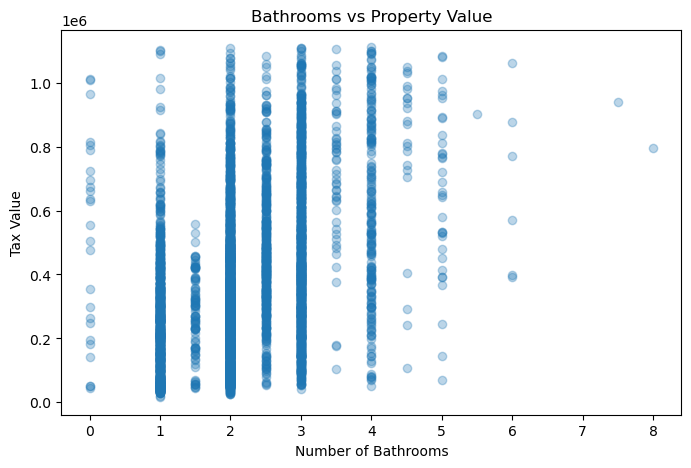

In [42]:
# Scatter plot: bathroom count vs target value
plt.figure(figsize=(8,5))
plt.scatter(df_plot['bathroomcnt'], df_plot['taxvaluedollarcnt'], alpha=0.3)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Tax Value")
plt.title("Bathrooms vs Property Value")
plt.show()

The number of bathrooms shows a positive relationship with property value, although the relationship is more discrete compared to square footage. Properties with more bathrooms tend to have higher values, but there is noticeable variability within each category.

**Latitude vs Price**

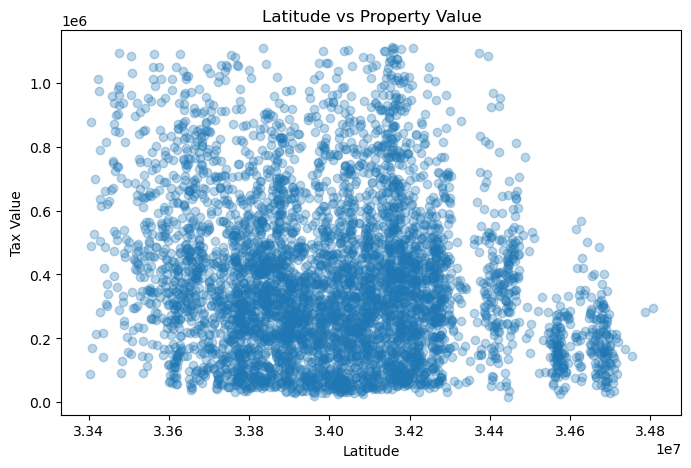

In [43]:
# Scatter plot: latitude vs target value
plt.figure(figsize=(8,5))
plt.scatter(df_plot['latitude'], df_plot['taxvaluedollarcnt'], alpha=0.3)
plt.xlabel("Latitude")
plt.ylabel("Tax Value")
plt.title("Latitude vs Property Value")
plt.show()

The relationship between latitude and property value appears weaker and less structured compared to other features. While there may be slight trends, the scatter suggests that location alone (as represented by latitude) does not fully explain property value and likely interacts with other geographic factors.

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


The scatter plot between finishedsquarefeet12 and taxvaluedollarcnt shows a clear positive relationship, with larger homes generally having higher property values, although there is noticeable variability, indicating the influence of additional factors. The relationship between bathroomcnt and the target is also positive but appears more discrete, with vertical groupings corresponding to the number of bathrooms and significant variation within each group. In contrast, the relationship between latitude and property value is less structured, with no clear linear trend, suggesting that location alone does not fully explain variations in property value and likely interacts with other geographic features. These visualizations confirm the earlier findings from correlation and F-statistic analysis, highlighting the importance of property size and structure while showing that some features have weaker or more complex relationships.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

**Log Transformation**

In [46]:
def add_log_features(df):
    df_new = df.copy()
    
    df_new['log_taxvalue'] = np.log1p(df_new['taxvaluedollarcnt'])
    df_new['log_lotsize'] = np.log1p(df_new['lotsizesquarefeet'])
    
    return df_new

df_log = add_log_features(df_imputed)

In [47]:
# Correlation with log target
df_log.corr()['log_taxvalue'].sort_values(ascending=False).head(10)

log_taxvalue                    1.000000
taxvaluedollarcnt               0.912916
finishedsquarefeet12            0.397712
calculatedfinishedsquarefeet    0.392952
calculatedbathnbr               0.377256
bathroomcnt                     0.370824
fullbathcnt                     0.348360
yearbuilt                       0.271313
buildingqualitytypeid           0.227044
bedroomcnt                      0.185329
Name: log_taxvalue, dtype: float64

**Polynomial Feature**

In [48]:
def add_polynomial_features(df):
    df_new = df.copy()
    
    df_new['sqft_squared'] = df_new['finishedsquarefeet12'] ** 2
    
    return df_new

df_poly = add_polynomial_features(df_imputed)

In [49]:
df_poly.corr()['taxvaluedollarcnt'].sort_values(ascending=False).head(10)

taxvaluedollarcnt               1.000000
finishedsquarefeet12            0.480140
calculatedfinishedsquarefeet    0.474307
sqft_squared                    0.447130
calculatedbathnbr               0.403380
bathroomcnt                     0.395146
fullbathcnt                     0.375483
bedroomcnt                      0.228156
yearbuilt                       0.221200
buildingqualitytypeid           0.202420
Name: taxvaluedollarcnt, dtype: float64

**Ratio Feature**

In [50]:
def add_ratio_features(df):
    df_new = df.copy()
    
    df_new['bath_bed_ratio'] = df_new['bathroomcnt'] / (df_new['bedroomcnt'] + 1)
    
    return df_new

df_ratio = add_ratio_features(df_imputed)

In [51]:
df_ratio.corr()['taxvaluedollarcnt'].sort_values(ascending=False).head(10)

taxvaluedollarcnt               1.000000
finishedsquarefeet12            0.480140
calculatedfinishedsquarefeet    0.474307
calculatedbathnbr               0.403380
bathroomcnt                     0.395146
fullbathcnt                     0.375483
bath_bed_ratio                  0.253114
bedroomcnt                      0.228156
yearbuilt                       0.221200
buildingqualitytypeid           0.202420
Name: taxvaluedollarcnt, dtype: float64

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


Several feature engineering transformations were explored to better capture relationships in the data. First, logarithmic transformations were applied to the target variable and lot size to reduce skewness and compress extreme values. While this transformation did not significantly increase correlations, it helped stabilize the distribution of the target variable, which may benefit certain models.

Second, a polynomial feature was created by squaring the finished square footage. This feature maintained a strong relationship with the target, suggesting that there may be some nonlinear effects in how property size influences value.

Third, a ratio feature representing bathrooms per bedroom was introduced to capture aspects of property layout and usability. This feature showed a moderate correlation with the target, indicating that it provides additional information beyond raw feature counts, although it is less influential than primary size-related features.

Overall, these transformations highlight potential improvements in feature representation, though their final usefulness will depend on the modeling approach used in later stages.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

